In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
name = ['SK1-052 9.6 kPa-650C', 'TCM2-027 9.6 kPa-650C', 'TCM2-071 9.6 kPa-650C']
number = ['45', '22', '16']

exp = {}

for sname, anum in zip(name, number):
    df = pd.read_excel('230319 TCM Al content 9.6 kPa.xlsx', sheet_name=sname)
    df.columns = df.columns.str.strip()

    time_col, total_al_col, al_col, error_col, rate_col = 'Time / h', 'Total Al / uc', 'Al/uc', 'Error Al/uc', 'Rate / mol ucˆ-1 hˆ-1'
    si_al_col = 'Si/Al'

    df_clean = df[[time_col, total_al_col, al_col, error_col, rate_col]].dropna()

    time_data      = pd.to_numeric(df_clean[time_col], errors='coerce').to_numpy()
    total_al_data  = pd.to_numeric(df_clean[total_al_col], errors='coerce').to_numpy()
    al_f_data   = pd.to_numeric(df_clean[al_col], errors='coerce').to_numpy()
    errors_data    = pd.to_numeric(df_clean[error_col], errors='coerce').to_numpy()
    rate_data      = pd.to_numeric(df_clean[rate_col], errors='coerce').to_numpy()

    exp[anum] = {
        'time':  time_data,
        'Al_f':  al_f_data,
        'Al_tot': total_al_data[0],
        'error': errors_data,
        'rate':  rate_data,
    }

exp

{'45': {'time': array([ 0,  2,  4,  8, 16, 32, 64]),
  'Al_f': array([0.57789749, 0.44603443, 0.35156755, 0.30445075, 0.19023879,
         0.11902728, 0.06838535]),
  'Al_tot': np.float64(0.7539061007838296),
  'error': array([0.0693477 , 0.05352413, 0.04218811, 0.03653409, 0.02282866,
         0.01428327, 0.00820624]),
  'rate': array([0.08068456, 0.0485394 , 0.03237917, 0.01733956, 0.00734544,
         0.00254685, 0.00076691])},
 '22': {'time': array([ 0. ,  1. ,  1.5,  2. ,  4. ,  6. ,  8. , 12. , 16. , 22. ]),
  'Al_f': array([1.06353382, 0.76429995, 0.66095391, 0.62854063, 0.4747066 ,
         0.37568761, 0.30533399, 0.22265274, 0.1805682 , 0.14812072]),
  'Al_tot': np.float64(1.4662980027207297),
  'error': array([0.12762406, 0.09171599, 0.07931447, 0.07542488, 0.05696479,
         0.04508251, 0.03664008, 0.02671833, 0.02166818, 0.01777449]),
  'rate': array([0.4178794 , 0.20170608, 0.15305055, 0.12053673, 0.05845077,
         0.03500953, 0.02353397, 0.0129365 , 0.00827638, 0.004

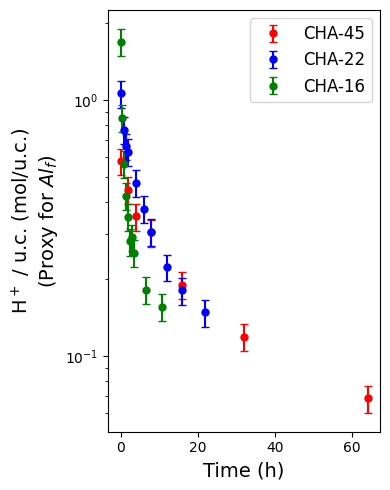

In [79]:
name_list = ['CHA-45', 'CHA-22', 'CHA-16']
colors = {'45': 'r', '22': 'b', '16': 'g'}

fig, ax = plt.subplots(figsize=(4, 5))

for idx, key in enumerate(['45','22','16']):
    ax.errorbar(
        exp[key]['time'],
        exp[key]['Al_f'],
        yerr=exp[key]['error'],
        fmt='o',
        markersize=5,
        capsize=3,
        linewidth=1.5,
        label=name_list[idx],
        color = colors[key]
    )

ax.set_xlabel('Time (h)', fontsize=14)
ax.set_ylabel('H$^+$ / u.c. (mol/u.c.)\n(Proxy for $Al_f$)', fontsize=14)
ax.set_yscale("log")
ax.legend(fontsize=12)
fig.tight_layout()
plt.show()

In [19]:
def integrated_rate_law(t, k_app, n, Al_f0):
    """
    Integrated rate law for -d[Al_f]/dt = k_app * [Al_f]^n
    
    For n ≠ 1: [Al_f]^(1-n) = [Al_f0]^(1-n) - k_app*(1-n)*t
    For n = 1: ln([Al_f]) = ln([Al_f0]) - k_app*t
    
    We use a smooth approximation near n=1 to avoid singularity
    """
    epsilon = 1e-6  # threshold for considering n ≈ 1
    
    if abs(n - 1) < epsilon:
        # First-order kinetics: [Al_f] = [Al_f0] * exp(-k_app*t)
        return Al_f0 * np.exp(-k_app * t)
    else:
        # General order kinetics
        term = Al_f0**(1-n) - k_app * (1-n) * t
        # Ensure we don't get negative values under the power
        term = np.maximum(term, 1e-10)
        return term**(1/(1-n))

In [53]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
# Fit each dataset
results = {}

for key, dataset in exp.items():
    time = dataset['time']
    Al_f = dataset['Al_f']
    Al_f0 = Al_f[0]  # Initial concentration
    
    # Initial guesses: k_app ~ 0.01, n ~ 1 (first order)
    # We'll try multiple initial guesses to avoid local minima
    initial_guesses = [
        (0.01, 1.0, Al_f0),
        (0.1, 0.5, Al_f0),
        (0.05, 1.5, Al_f0),
        (0.001, 2.0, Al_f0)
    ]
    
    best_fit = None
    best_error = np.inf
    
    for guess in initial_guesses:
        try:
            # Fit the data
            popt, pcov = curve_fit(
                integrated_rate_law, 
                time, 
                Al_f, 
                p0=guess,
                bounds=([0, 0, Al_f0*0.9], [np.inf, 5, Al_f0*1.1]),
                maxfev=10000
            )
            
            # Calculate residual error
            predicted = integrated_rate_law(time, *popt)
            error = np.sum((Al_f - predicted)**2)
            
            if error < best_error:
                best_error = error
                best_fit = (popt, pcov)
        except:
            continue
    
    if best_fit is not None:
        popt, pcov = best_fit
        k_app, n, Al_f0_fit = popt
        
        # Calculate standard errors
        perr = np.sqrt(np.diag(pcov))
        
        # Calculate R²
        predicted = integrated_rate_law(time, *popt)
        ss_res = np.sum((Al_f - predicted)**2)
        ss_tot = np.sum((Al_f - np.mean(Al_f))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        results[key] = {
            'k_app': k_app,
            'n': n,
            'Al_f0': Al_f0_fit,
            'k_app_err': perr[0],
            'n_err': perr[1],
            'R2': r_squared
        }
        
        print(f"\n{'='*60}")
        print(f"Dataset: {key}")
        print(f"{'='*60}")
        print(f"Apparent rate constant (k_app): {k_app:.6f} ± {perr[0]:.6f}")
        print(f"Reaction order (n):              {n:.4f} ± {perr[1]:.4f}")
        print(f"Initial [Al_f]:                  {Al_f0_fit:.6f} ± {perr[2]:.6f}")
        print(f"R²:                              {r_squared:.6f}")


Dataset: 45
Apparent rate constant (k_app): 0.284419 ± 0.066554
Reaction order (n):              2.2224 ± 0.2021
Initial [Al_f]:                  0.574042 ± 0.015609
R²:                              0.994688

Dataset: 22
Apparent rate constant (k_app): 0.357948 ± 0.021087
Reaction order (n):              2.2778 ± 0.0928
Initial [Al_f]:                  1.056733 ± 0.015970
R²:                              0.997607

Dataset: 16
Apparent rate constant (k_app): 1.210800 ± 0.063497
Reaction order (n):              2.2956 ± 0.1115
Initial [Al_f]:                  1.694248 ± 0.028817
R²:                              0.997007


In [74]:
def log_integrated_rate_law(t, k_app, n, Al_f0):
    """Wrapper that returns log([Al_f]) for log-space fitting."""
    Al_f = integrated_rate_law(t, k_app, n, Al_f0)
    return np.log(np.maximum(Al_f, 1e-10))

results = {}
for key, dataset in exp.items():
    time = dataset['time']
    Al_f = dataset['Al_f']
    Al_f0 = Al_f[0]
    log_Al_f = np.log(Al_f)  # <-- fit target is now log([Al_f])

    initial_guesses = [
        (0.01, 1.0, Al_f0),
        (0.1,  0.5, Al_f0),
        (0.05, 1.5, Al_f0),
        (0.001,2.0, Al_f0),
    ]

    best_fit, best_error = None, np.inf

    for guess in initial_guesses:
        try:
            popt, pcov = curve_fit(
                log_integrated_rate_law,   # <-- log-space model
                time,
                log_Al_f,                  # <-- log-space data
                p0=guess,
                bounds=([0, 0, Al_f0*0.9], [np.inf, 5, Al_f0*1.1]),
                maxfev=10000
            )
            predicted_log = log_integrated_rate_law(time, *popt)
            error = np.sum((log_Al_f - predicted_log)**2)
            if error < best_error:
                best_error = error
                best_fit = (popt, pcov)
        except:
            continue

    if best_fit is not None:
        popt, pcov = best_fit
        k_app, n, Al_f0_fit = popt
        perr = np.sqrt(np.diag(pcov))

        # R² in log-space (what you're actually optimizing)
        predicted_log = log_integrated_rate_law(time, *popt)
        ss_res = np.sum((log_Al_f - predicted_log)**2)
        ss_tot = np.sum((log_Al_f - np.mean(log_Al_f))**2)
        r_squared_log = 1 - ss_res / ss_tot

        results[key] = {
            'k_app': k_app, 'n': n, 'Al_f0': Al_f0_fit,
            'k_app_err': perr[0], 'n_err': perr[1],
            'R2': r_squared_log
        }

In [75]:
results

{'45': {'k_app': np.float64(0.23797397887393512),
  'n': np.float64(2.087684846152382),
  'Al_f0': np.float64(0.5649468549993275),
  'k_app_err': np.float64(0.039324291319203404),
  'n_err': np.float64(0.09889512529609562),
  'R2': np.float64(0.997073932048669)},
 '22': {'k_app': np.float64(0.3256662238278975),
  'n': np.float64(2.150977049906438),
  'Al_f0': np.float64(1.037505312002706),
  'k_app_err': np.float64(0.021932352802844605),
  'n_err': np.float64(0.06655003968056783),
  'R2': np.float64(0.9979974010831062)},
 '16': {'k_app': np.float64(1.4626714831045065),
  'n': np.float64(2.649822049866707),
  'Al_f0': np.float64(1.733232902991083),
  'k_app_err': np.float64(0.17024548675001167),
  'n_err': np.float64(0.14037556541633014),
  'R2': np.float64(0.9868565348716212)}}

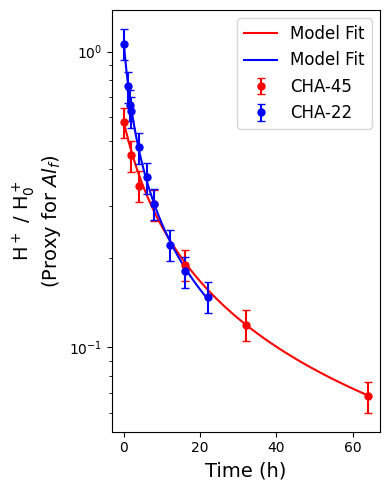

In [87]:

fig, ax = plt.subplots(figsize=(4, 5))
for key in ['45','22']:
    # key = '45'
    k=results[key]['k_app']
    n=results[key]['n']
    Alf0 = exp[key]['Al_f'][0]
    t=np.linspace(0,exp[key]['time'][-1],100)
    f = lambda t: (Alf0**(1-n)+(n-1)*k*t)**(1/(1-n))
    plt.errorbar(
            exp[key]['time'],
            exp[key]['Al_f'],
            yerr=exp[key]['error'],
            fmt='o',
            markersize=5,
            capsize=3,
            linewidth=1.5,
            label=f'CHA-{key}',
            color = colors[key]
        )
    plt.plot(t, f(t), color = colors[key],label='Model Fit')
plt.xlabel('Time (h)', fontsize=14)
plt.ylabel('H$^+$ / H$^+_0$\n(Proxy for $Al_f$)', fontsize=14)
plt.yscale("log")
plt.legend(fontsize=12)
fig.tight_layout()
plt.show()

In [61]:
k

np.float64(1.2108004694116368)

In [ ]:
time = dataset['time']
Al_f = dataset['Al_f']

if key in results:
    k_app = results[key]['k_app']
    n = results[key]['n']
    Al_f0 = results[key]['Al_f0']
    
    # Generate smooth curve
    t_smooth = np.linspace(0, time[-1], 100)
    Al_f_fit = integrated_rate_law(t_smooth, k_app, n, Al_f0)
    
    axes[idx].errorbar(time, Al_f, yerr=dataset['error'], fmt='o', label=f'CHA-{key}', markersize=8)
    axes[idx].plot(t_smooth, Al_f_fit, '-', label='Fit', linewidth=2)
    axes[idx].set_xlabel('Time', fontsize=14)
    axes[idx].set_ylabel(r'$[Al_f]$', fontsize=14)
    # axes[idx].set_yscale('log')
    # axes[idx].set_title(f'Dataset {key}\nk_app={k_app:.4f}, n={n:.2f}', fontsize=16)
    axes[idx].set_ylim(0.05,exp['16']['Al_tot']+0.1)
    axes[idx].set_xlim(-5,exp['45']['time'][-1]+5)
    axes[idx].legend(fontsize=14)

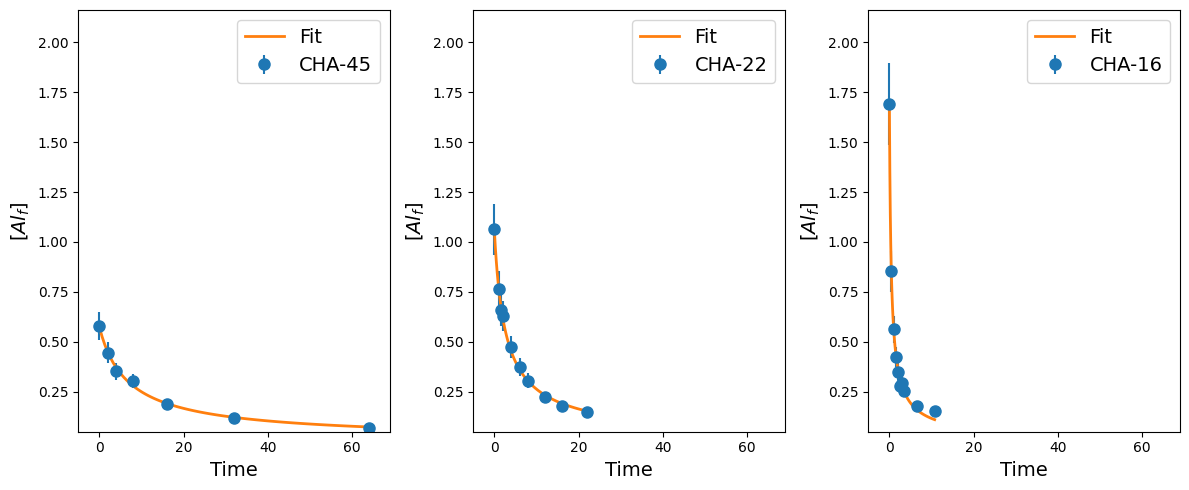

In [20]:
# Plot results
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for idx, (key, dataset) in enumerate(exp.items()):
    time = dataset['time']
    Al_f = dataset['Al_f']
    
    if key in results:
        k_app = results[key]['k_app']
        n = results[key]['n']
        Al_f0 = results[key]['Al_f0']
        
        # Generate smooth curve
        t_smooth = np.linspace(0, time[-1], 100)
        Al_f_fit = integrated_rate_law(t_smooth, k_app, n, Al_f0)
        
        axes[idx].errorbar(time, Al_f, yerr=dataset['error'], fmt='o', label=f'CHA-{key}', markersize=8)
        axes[idx].plot(t_smooth, Al_f_fit, '-', label='Fit', linewidth=2)
        axes[idx].set_xlabel('Time', fontsize=14)
        axes[idx].set_ylabel(r'$[Al_f]$', fontsize=14)
        # axes[idx].set_yscale('log')
        # axes[idx].set_title(f'Dataset {key}\nk_app={k_app:.4f}, n={n:.2f}', fontsize=16)
        axes[idx].set_ylim(0.05,exp['16']['Al_tot']+0.1)
        axes[idx].set_xlim(-5,exp['45']['time'][-1]+5)
        axes[idx].legend(fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
dataset